# Week 2 Day 2 — Duration and DV01 on Real Bond Data

We test `modified_duration` and `dv01` using real CMT benchmark yields.

**Setup:** for each CMT maturity (0.25Y, 1Y, 2Y, 5Y, 10Y, 30Y) we treat the observed yield as the YTM of a par bond — meaning coupon = YTM so price = 100. This is a standard and clean way to work with benchmark yields: a freshly-issued on-the-run bond is always priced at par.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.termstructure.bonds.pricing import (
    price_from_ytm,
    ytm_from_price,
    modified_duration,
    dv01,
)

## 1. Load real CMT yields for a single date

In [2]:
cmt = pd.read_parquet('../data/processed/cmt_yields.parquet')

# Pick the most recent date in the dataset
latest_date = cmt['date'].max()
print(f'Using date: {latest_date.date()}')

snapshot = cmt[cmt['date'] == latest_date].copy()
snapshot['ytm'] = snapshot['yield_pct'] / 100   # convert pct to decimal
snapshot = snapshot.sort_values('maturity_years').reset_index(drop=True)
snapshot[['maturity_years', 'yield_pct', 'ytm']]

Using date: 2020-12-31


,maturity_years,yield_pct,ytm
0,0.25,0.09,0.0009
1,1.00,0.10,0.0010
2,2.00,0.13,0.0013
3,5.00,0.36,0.0036
4,10.00,0.93,0.0093
5,30.00,1.65,0.0165


## 2. Price check — par bonds should price at 100

For a par bond, coupon = YTM by definition. So `price_from_ytm(coupon=ytm, ..., ytm=ytm)` must return exactly 100. This verifies our pricing function is consistent.

In [3]:
snapshot['price'] = snapshot.apply(
    lambda r: price_from_ytm(
        coupon=r['ytm'],
        maturity_years=r['maturity_years'],
        ytm=r['ytm'],
    ),
    axis=1,
)

snapshot[['maturity_years', 'yield_pct', 'price']]

,maturity_years,yield_pct,price
0,0.25,0.09,100.0
1,1.00,0.10,100.0
2,2.00,0.13,100.0
3,5.00,0.36,100.0
4,10.00,0.93,100.0
5,30.00,1.65,100.0


In [4]:
# All prices should be within floating-point noise of 100
max_error = (snapshot['price'] - 100).abs().max()
print(f'Max price deviation from 100: {max_error:.2e}')
assert max_error < 1e-8, 'Par bond price check failed'

Max price deviation from 100: 4.26e-13


## 3. YTM round-trip — recover yield from price

We just priced the par bonds at 100. Now we go the other direction: feed that price back into `ytm_from_price` and check we get the original YTM back. A good implementation recovers to better than 0.01 bp.

**Note on T-bills:** the 3-month (0.25Y) entry is excluded here. With `freq=2`, that maturity maps to `n = round(0.25 × 2) = round(0.5) = 0` coupon periods (Python banker's rounding). Zero periods makes `price_from_ytm` return 100 for any yield, so round-trip recovery is undefined. T-bills are zero-coupon discount instruments with a different pricing convention than coupon bonds — they don't belong in this test.

In [5]:
bonds = snapshot[snapshot['maturity_years'] >= 1.0].copy()

bonds['ytm_recovered'] = bonds.apply(
    lambda r: ytm_from_price(
        price=r['price'],
        coupon=r['ytm'],
        maturity_years=r['maturity_years'],
    ),
    axis=1,
)

bonds['ytm_error_bp'] = (bonds['ytm_recovered'] - bonds['ytm']).abs() * 10000

bonds[['maturity_years', 'yield_pct', 'ytm_recovered', 'ytm_error_bp']]

,maturity_years,yield_pct,ytm_recovered,ytm_error_bp
1,1.0,0.10,0.0010,1.609780e-10
2,2.0,0.13,0.0013,2.304387e-09
3,5.0,0.36,0.0036,3.270314e-09
4,10.0,0.93,0.0093,9.887924e-13
5,30.0,1.65,0.0165,0.000000e+00


In [6]:
max_ytm_err = bonds['ytm_error_bp'].max()
print(f'Max YTM round-trip error: {max_ytm_err:.4f} bp')
assert max_ytm_err < 0.01, 'YTM round-trip error too large'

Max YTM round-trip error: 0.0000 bp


## 4. Modified duration across the yield curve

Modified duration rises with maturity. A 3-month bill has near-zero duration (it matures soon regardless of yield). A 30-year bond has duration around 20 — so a 1% yield move changes its price by ~20%.

In [7]:
snapshot['mod_dur'] = snapshot.apply(
    lambda r: modified_duration(
        coupon=r['ytm'],
        maturity_years=r['maturity_years'],
        ytm=r['ytm'],
    ),
    axis=1,
)

snapshot[['maturity_years', 'yield_pct', 'mod_dur']]

,maturity_years,yield_pct,mod_dur
0,0.25,0.09,0.000000
1,1.00,0.10,0.999251
2,2.00,0.13,1.996754
3,5.00,0.36,4.950855
4,10.00,0.93,9.527966
5,30.00,1.65,23.587303


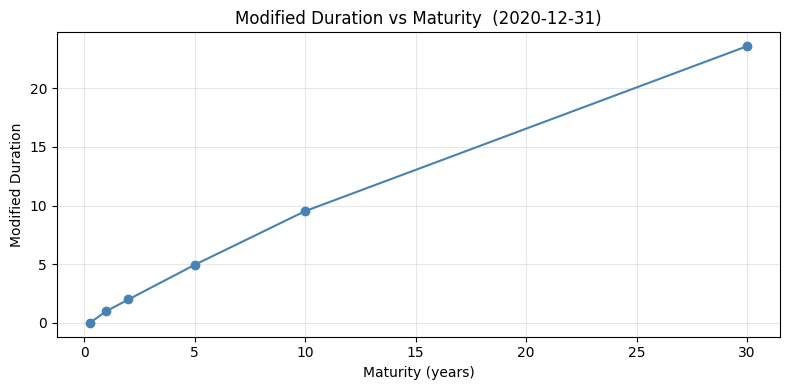

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(snapshot['maturity_years'], snapshot['mod_dur'], 'o-', color='steelblue')
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Modified Duration')
ax.set_title(f'Modified Duration vs Maturity  ({latest_date.date()})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. DV01 across the yield curve

DV01 is the dollar risk per \$100 face for a 1bp move. Since both duration and price scale with maturity, DV01 grows sharply as you go out the curve.

In [9]:
snapshot['dv01'] = snapshot.apply(
    lambda r: dv01(
        coupon=r['ytm'],
        maturity_years=r['maturity_years'],
        ytm=r['ytm'],
    ),
    axis=1,
)

# Also compute DV01 for a $1M face position (scale by 10,000)
snapshot['dv01_1m_pos'] = snapshot['dv01'] * 10_000

snapshot[['maturity_years', 'yield_pct', 'dv01', 'dv01_1m_pos']]

,maturity_years,yield_pct,dv01,dv01_1m_pos
0,0.25,0.09,0.000000,0.000000
1,1.00,0.10,0.009993,99.925050
2,2.00,0.13,0.019968,199.675425
3,5.00,0.36,0.049509,495.085460
4,10.00,0.93,0.095280,952.796569
5,30.00,1.65,0.235873,2358.730319


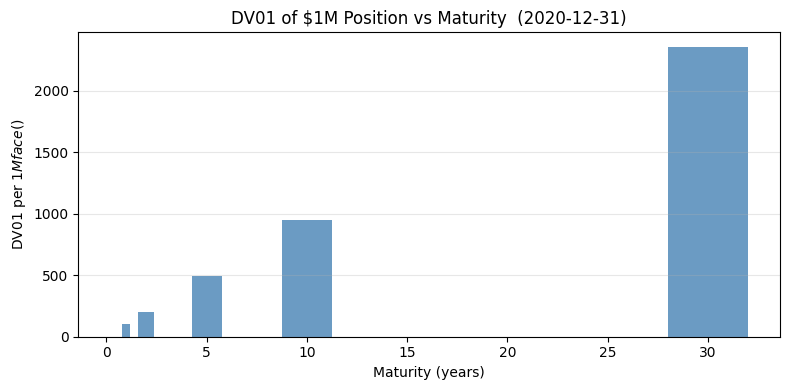

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(snapshot['maturity_years'], snapshot['dv01_1m_pos'],
       width=[0.1, 0.4, 0.8, 1.5, 2.5, 4], color='steelblue', alpha=0.8)
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('DV01 per $1M face ($)')
ax.set_title(f'DV01 of $1M Position vs Maturity  ({latest_date.date()})')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 6. How DV01 changes as yield moves

DV01 is not constant — it changes as the yield level changes. This is called **convexity**. As yields rise, duration falls slightly, so DV01 decreases. This asymmetry (you lose less than you gain for equal yield moves in each direction) is why convexity is a valuable property in bonds.

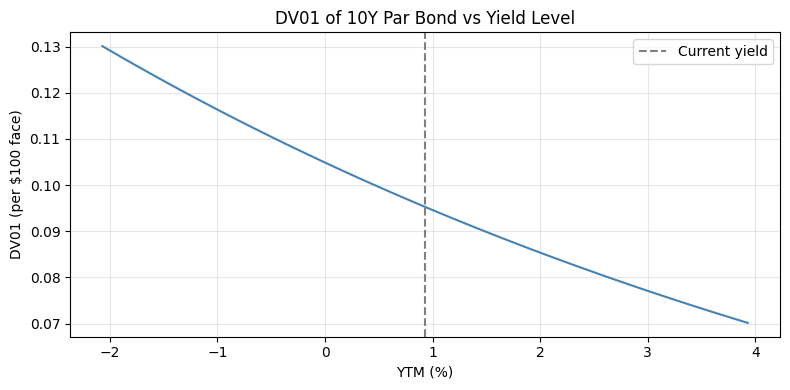

DV01 falls as yields rise — this is convexity.


In [11]:
# Focus on the 10Y bond
row_10y = snapshot[snapshot['maturity_years'] == 10.0].iloc[0]
base_ytm = row_10y['ytm']
coupon   = row_10y['ytm']  # par bond

ytm_range = np.linspace(base_ytm - 0.03, base_ytm + 0.03, 61)  # ±300bp
dv01_range = [dv01(coupon, 10, y) for y in ytm_range]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ytm_range * 100, dv01_range, color='steelblue')
ax.axvline(base_ytm * 100, color='gray', linestyle='--', label='Current yield')
ax.set_xlabel('YTM (%)')
ax.set_ylabel('DV01 (per $100 face)')
ax.set_title('DV01 of 10Y Par Bond vs Yield Level')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('DV01 falls as yields rise — this is convexity.')

## 7. Summary table

In [12]:
summary = snapshot[['maturity_years', 'yield_pct', 'price', 'mod_dur', 'dv01', 'dv01_1m_pos']].copy()
summary.columns = ['Maturity (Y)', 'YTM (%)', 'Price', 'Mod Duration', 'DV01 / $100', 'DV01 / $1M']
summary = summary.round({'YTM (%)': 3, 'Price': 6, 'Mod Duration': 4, 'DV01 / $100': 6, 'DV01 / $1M': 2})
summary

,Maturity (Y),YTM (%),Price,Mod Duration,DV01 / $100,DV01 / $1M
0,0.25,0.09,100.0,0.0000,0.000000,0.00
1,1.00,0.10,100.0,0.9993,0.009993,99.93
2,2.00,0.13,100.0,1.9968,0.019968,199.68
3,5.00,0.36,100.0,4.9509,0.049509,495.09
4,10.00,0.93,100.0,9.5280,0.095280,952.80
5,30.00,1.65,100.0,23.5873,0.235873,2358.73
